In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
# import colorcet as cc
import copy, os
import colormaps as cmaps
import easygems.healpix as egh

In [2]:
rootdir = '/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/'
name_map = {
    'obs': 'IMERGv7',
    'm1': 'scream',
    'm2': 'icon_d3hp003',
    'm3': 'nicam_gl11',
    'm4': 'casesm2_10km_nocumulus',
}
name_map_plot = {
    'obs': 'OBS',
    'm1': 'SCREAM',
    'm2': 'ICON',
    'm3': 'NICAM',
    'm4': 'CASESM2',
}

# Input filenames
filenames = {key:f'{rootdir}{value}_monthly_rainmap_cof_hp8_v1.nc' for key,value in name_map.items()}

landmaskfile = '/global/cfs/cdirs/m4581/gsharing/hackathon/scream-cess-healpix/scream2D_hrly_topo_hp8_v7.zarr'

figdir = '/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/'
os.makedirs(figdir, exist_ok=True)
print(figdir)

/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/


### Check if input files exist

In [3]:
for key, value in filenames.items():
    print(f'{value}: {os.path.isfile(value)}')

/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/IMERGv7_monthly_rainmap_cof_hp8_v1.nc: True
/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/scream_monthly_rainmap_cof_hp8_v1.nc: True
/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/icon_d3hp003_monthly_rainmap_cof_hp8_v1.nc: True
/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/nicam_gl11_monthly_rainmap_cof_hp8_v1.nc: True
/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/casesm2_10km_nocumulus_monthly_rainmap_cof_hp8_v1.nc: True


In [4]:
dstop = xr.open_dataset(landmaskfile)
ter = dstop.ELEV
landfrac = dstop.LANDFRAC
dstop

<xarray.Dataset> Size: 13MB
Dimensions:   (cell: 786432, crs: 0)
Coordinates:
  * crs       (crs) float64 0B 
Dimensions without coordinates: cell
Data variables:
    ELEV      (cell) float32 3MB ...
    LANDFRAC  (cell) float32 3MB ...
    lat       (cell) float32 3MB ...
    lon       (cell) float32 3MB ...
Attributes:
    NCO:                        netCDF Operators version 4.9.8-alpha01 (Homep...
    history:                    Fri Jun 11 12:26:48 2021: ncks -A USGS-gtopo3...
    history_of_appended_files:  Fri Jun 11 12:26:48 2021: Appended file USGS-...
    source:                     USGS 30-sec dataset binned to ncube3000 (cube...
    title:                      30-second USGS topo data

<Figure size 640x480 with 0 Axes>

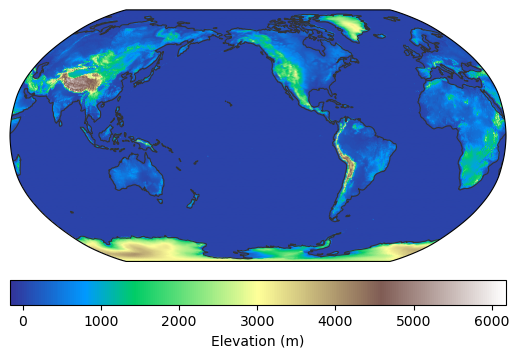

In [5]:
im = egh.healpix_show(ter, cmap='terrain')
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Elevation (m)')

<Figure size 640x480 with 0 Axes>

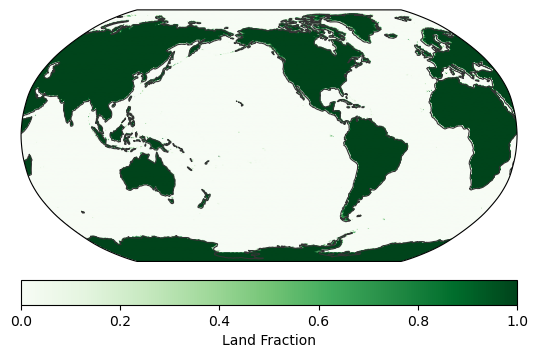

In [6]:
im = egh.healpix_show(landfrac, cmap='Greens', vmin=0, vmax=1)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Land Fraction')

## Read and combine all sources to a single DataSet

In [7]:
drop_vars = []
# Read all files and combine them with a new dimension 'source'
ds = xr.open_mfdataset(list(filenames.values()), combine='nested', concat_dim='source', drop_variables=drop_vars).squeeze()
# Assign new coordinate 'source' using name_map dictionary keys
ds['source'] = list(name_map.keys())
# ds = ds.pipe(egh.attach_coords)
# Load lat/lon coordinates in memory
hp_lat = ds.lat.load()
hp_lon = ds.lon.load()
ds

<xarray.Dataset> Size: 11GB
Dimensions:                         (source: 5, time: 20, cell: 786432)
Coordinates:
  * time                            (time) datetime64[ns] 160B 2019-08-01 ......
  * cell                            (cell) int32 3MB 0 1 2 ... 786430 786431
    lat                             (cell) float64 6MB 0.1492 0.2984 ... -0.1492
    lon                             (cell) float64 6MB 45.0 45.18 ... 315.0
    crs                             int64 8B 0
  * source                          (source) <U3 60B 'obs' 'm1' 'm2' 'm3' 'm4'
Data variables: (12/35)
    precipitation                   (source, time, cell) float32 315MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    ntimes                          (source, time) float32 400B dask.array<chunksize=(1, 12), meta=np.ndarray>
    mcs_precipitation               (source, time, cell) float32 315MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    mcs_count                       (source, time, cell) float32 315MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    mcs_precipitation_count         (source, time, cell) float32 315MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    ar_precipitation                (source, time, cell) float32 315MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    ...                              ...
    ar_etc_precipitation            (source, time, cell) float32 315MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    ar_etc_count                    (source, time, cell) float32 315MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    ar_etc_precipitation_count      (source, time, cell) float32 315MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    mcs_ar_etc_precipitation        (source, time, cell) float32 315MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    mcs_ar_etc_count                (source, time, cell) float32 315MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    mcs_ar_etc_precipitation_count  (source, time, cell) float32 315MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
Attributes:
    Title:                    Monthly precipitation statistics by co-occurren...
    contact:                  Zhe Feng, zhe.feng@pnnl.gov
    created_on:               Tue Oct 14 11:27:23 2025
    grid_type:                HEALPix
    zoom_level:               8
    time_interval:            6.0
    precipitation_threshold:  0.1

In [8]:
ds.ntimes.sum(dim='time').values

array([1588., 3152., 1460., 1459., 1459.], dtype=float32)

In [9]:
# Get time interval from attributes
time_interval = float(ds.attrs['time_interval'])

# Calculate total hours accounting for time interval
# ntimes is the number of timesteps, multiply by time_interval to get actual hours
ntimes = ds.ntimes.sum(dim='time')
nhours = ntimes * time_interval

# Sum monthly precipitation amount [mm], divided by total hours to get mm/day
tot_pcp_all = (24. * ds.precipitation.sum(dim='time') / nhours).compute()

# Original features
mcs_pcp_all = (24. * ds.mcs_precipitation.sum(dim='time') / nhours).compute()
ar_pcp_all = (24. * ds.ar_precipitation.sum(dim='time') / nhours).compute()
etc_pcp_all = (24. * ds.etc_precipitation.sum(dim='time') / nhours).compute()
tc_pcp_all = (24. * ds.tc_precipitation.sum(dim='time') / nhours).compute()

# Isolated features only
mcs_iso_pcp_all = (24. * ds.mcs_iso_precipitation.sum(dim='time') / nhours).compute()
ar_iso_pcp_all = (24. * ds.ar_iso_precipitation.sum(dim='time') / nhours).compute()
etc_iso_pcp_all = (24. * ds.etc_iso_precipitation.sum(dim='time') / nhours).compute()
# Co-occurrence features
mcs_ar_pcp_all = (24. * ds.mcs_ar_precipitation.sum(dim='time') / nhours).compute()
mcs_etc_pcp_all = (24. * ds.mcs_etc_precipitation.sum(dim='time') / nhours).compute()
ar_etc_pcp_all = (24. * ds.ar_etc_precipitation.sum(dim='time') / nhours).compute()
mcs_ar_etc_pcp_all = (24. * ds.mcs_ar_etc_precipitation.sum(dim='time') / nhours).compute()

# Calculate precipitation fractions
# Original features
mcs_pcpfrac_all = 100. * mcs_pcp_all / tot_pcp_all
tc_pcpfrac_all = 100. * tc_pcp_all / tot_pcp_all

# Isolated features only
mcs_iso_pcpfrac_all = 100. * mcs_iso_pcp_all / tot_pcp_all
ar_iso_pcpfrac_all = 100. * ar_iso_pcp_all / tot_pcp_all
tc_pcpfrac_all = 100. * tc_pcp_all / tot_pcp_all
etc_iso_pcpfrac_all = 100. * etc_iso_pcp_all / tot_pcp_all
# Co-occurrence features
mcs_ar_pcpfrac_all = 100. * mcs_ar_pcp_all / tot_pcp_all
mcs_etc_pcpfrac_all = 100. * mcs_etc_pcp_all / tot_pcp_all
ar_etc_pcpfrac_all = 100. * ar_etc_pcp_all / tot_pcp_all
mcs_ar_etc_pcpfrac_all = 100. * mcs_ar_etc_pcp_all / tot_pcp_all

In [10]:
# mcs_pcp_sumcof_all = mcs_iso_pcp_all + mcs_ar_pcp_all + mcs_etc_pcp_all + mcs_ar_etc_pcp_all
# mcs_pcp_diff = mcs_pcp_sumcof_all - mcs_pcp_all

In [11]:
# im = egh.healpix_show(mcs_pcp_diff.sel(source='obs'), vmin=-4, vmax=4, cmap='BrBG')
# plt.colorbar(im, orientation='horizontal', pad=0.05, label='$\Delta$MCS Precipitation (mm/day)')

In [12]:
# Calculate number of feature mask hours
# Original features
mcs_count_all = ds.mcs_count.sum(dim='time').compute()
ar_count_all = ds.ar_count.sum(dim='time').compute()
etc_count_all = ds.etc_count.sum(dim='time').compute()
tc_count_all = ds.tc_count.sum(dim='time').compute()

# Isolated features only
mcs_iso_count_all = ds.mcs_iso_count.sum(dim='time').compute()
ar_iso_count_all = ds.ar_iso_count.sum(dim='time').compute()
etc_iso_count_all = ds.etc_iso_count.sum(dim='time').compute()
# Co-occurrence features
mcs_ar_count_all = ds.mcs_ar_count.sum(dim='time').compute()
mcs_etc_count_all = ds.mcs_etc_count.sum(dim='time').compute()
ar_etc_count_all = ds.ar_etc_count.sum(dim='time').compute()
mcs_ar_etc_count_all = ds.mcs_ar_etc_count.sum(dim='time').compute()

# Calculate feature mask frequencies (as percentages)
# Original features
mcs_freq_all = 100. * mcs_count_all / nhours
ar_freq_all = 100. * ar_count_all / nhours
etc_freq_all = 100. * etc_count_all / nhours
tc_freq_all = 100. * tc_count_all / nhours

# Isolated features only
mcs_iso_freq_all = 100. * mcs_iso_count_all / nhours
ar_iso_freq_all = 100. * ar_iso_count_all / nhours
etc_iso_freq_all = 100. * etc_iso_count_all / nhours
# Co-occurrence features
mcs_ar_freq_all = 100. * mcs_ar_count_all / nhours
mcs_etc_freq_all = 100. * mcs_etc_count_all / nhours
ar_etc_freq_all = 100. * ar_etc_count_all / nhours
mcs_ar_etc_freq_all = 100. * mcs_ar_etc_count_all / nhours

In [13]:
# mcs_all_freq_all = 100 * (mcs_iso_count_all + mcs_ar_count_all + mcs_etc_count_all + mcs_ar_etc_count_all) / nhours


In [14]:
# Number of feature precipitation hours
# Original features
mcs_pcpcount_all = ds.mcs_precipitation_count.sum(dim='time').compute()
ar_pcpcount_all = ds.ar_precipitation_count.sum(dim='time').compute()
etc_pcpcount_all = ds.etc_precipitation_count.sum(dim='time').compute()
tc_pcpcount_all = ds.tc_precipitation_count.sum(dim='time').compute()

# Isolated features only
mcs_iso_pcpcount_all = ds.mcs_precipitation_count.sum(dim='time').compute()
ar_iso_pcpcount_all = ds.ar_precipitation_count.sum(dim='time').compute()
etc_iso_pcpcount_all = ds.etc_precipitation_count.sum(dim='time').compute()
# Co-occurrence features
mcs_ar_pcpcount_all = ds.mcs_ar_precipitation_count.sum(dim='time').compute()
mcs_etc_pcpcount_all = ds.mcs_etc_precipitation_count.sum(dim='time').compute()
ar_etc_pcpcount_all = ds.ar_etc_precipitation_count.sum(dim='time').compute()
mcs_ar_etc_pcpcount_all = ds.mcs_ar_etc_precipitation_count.sum(dim='time').compute()

# Calculate feature frequencies (as percentages)
# Original features
mcs_pcpfreq_all = 100 * mcs_pcpcount_all / ntimes
ar_pcpfreq_all = 100 * ar_pcpcount_all / ntimes
etc_pcpfreq_all = 100 * etc_pcpcount_all / ntimes
tc_pcpfreq_all = 100 * tc_pcpcount_all / ntimes

# Isolated features only
mcs_iso_pcpfreq_all = 100 * mcs_iso_pcpcount_all / ntimes
ar_iso_pcpfreq_all = 100 * ar_iso_pcpcount_all / ntimes
etc_iso_pcpfreq_all = 100 * etc_iso_pcpcount_all / ntimes
# Co-occurrence features
mcs_ar_pcpfreq_all = 100 * mcs_ar_pcpcount_all / ntimes
mcs_etc_pcpfreq_all = 100 * mcs_etc_pcpcount_all / ntimes
ar_etc_pcpfreq_all = 100 * ar_etc_pcpcount_all / ntimes
mcs_ar_etc_pcpfreq_all = 100 * mcs_ar_etc_pcpcount_all / ntimes

<Figure size 640x480 with 0 Axes>

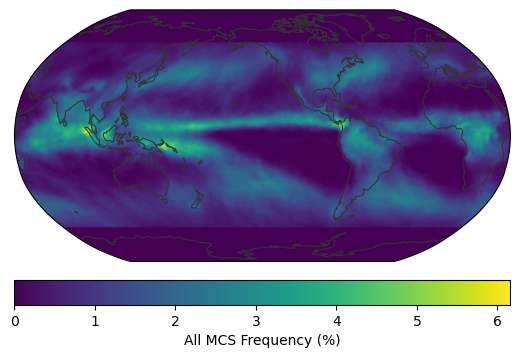

In [15]:
im = egh.healpix_show(mcs_freq_all.sel(source='obs'))
plt.colorbar(im, orientation='horizontal', pad=0.05, label='All MCS Frequency (%)')

<Figure size 640x480 with 0 Axes>

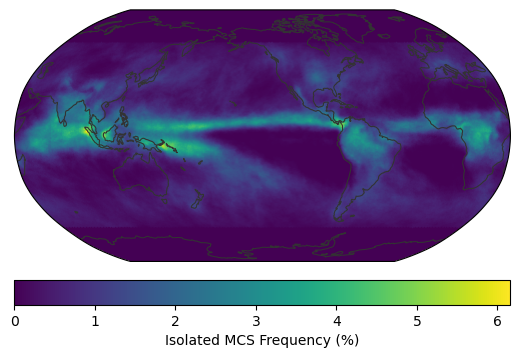

In [16]:
im = egh.healpix_show(mcs_iso_freq_all.sel(source='obs'))
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Isolated MCS Frequency (%)')

<Figure size 640x480 with 0 Axes>

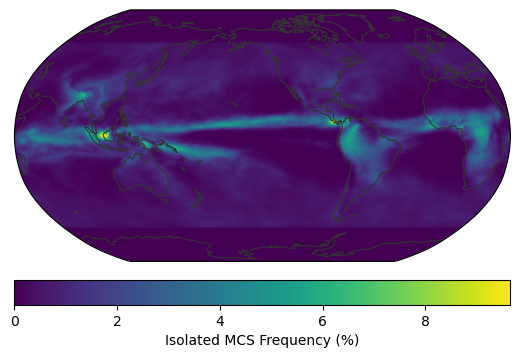

In [17]:
im = egh.healpix_show(mcs_iso_freq_all.sel(source='m1'))
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Isolated MCS Frequency (%)')

<Figure size 640x480 with 0 Axes>

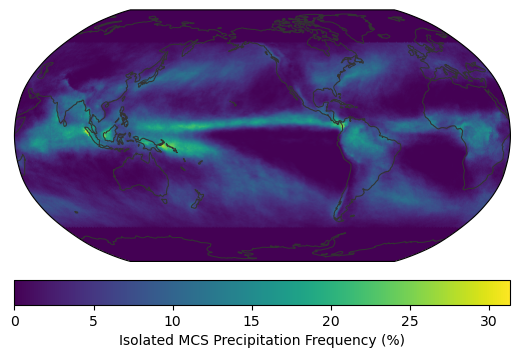

In [18]:
im = egh.healpix_show(mcs_iso_pcpfreq_all.sel(source='obs'))
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Isolated MCS Precipitation Frequency (%)')

<Figure size 640x480 with 0 Axes>

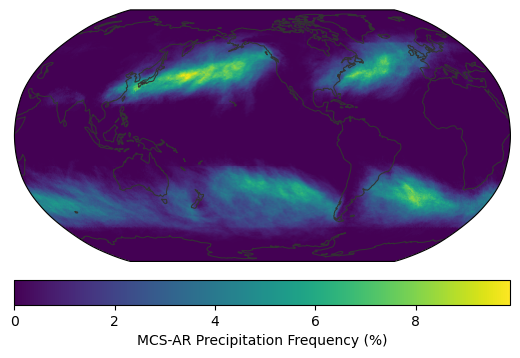

In [19]:
im = egh.healpix_show(mcs_ar_pcpfreq_all.sel(source='obs'))
plt.colorbar(im, orientation='horizontal', pad=0.05, label='MCS-AR Precipitation Frequency (%)')

<Figure size 640x480 with 0 Axes>

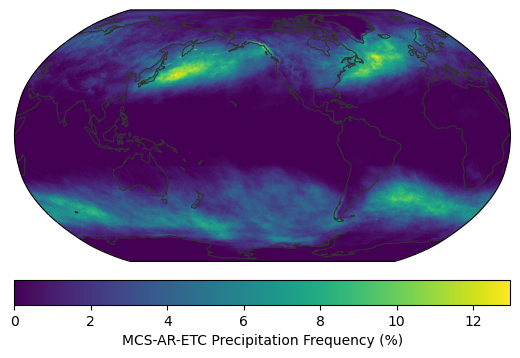

In [20]:
im = egh.healpix_show(mcs_ar_etc_pcpfreq_all.sel(source='obs'))
plt.colorbar(im, orientation='horizontal', pad=0.05, label='MCS-AR-ETC Precipitation Frequency (%)')

<Figure size 640x480 with 0 Axes>

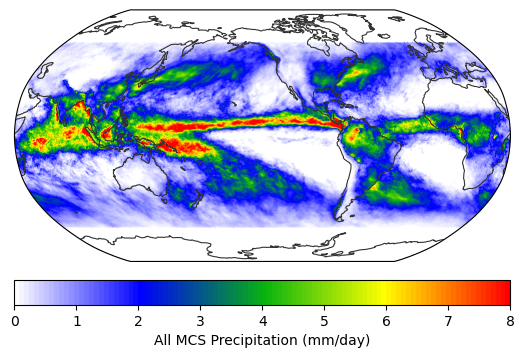

In [21]:
im = egh.healpix_show(mcs_pcp_all.sel(source='obs'), vmin=0, vmax=8, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='All MCS Precipitation (mm/day)')

<Figure size 640x480 with 0 Axes>

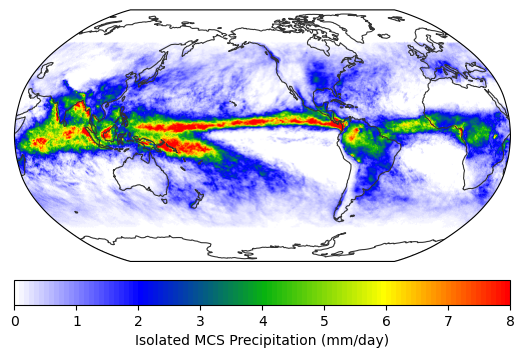

In [22]:
im = egh.healpix_show(mcs_iso_pcp_all.sel(source='obs'), vmin=0, vmax=8, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Isolated MCS Precipitation (mm/day)')

<Figure size 640x480 with 0 Axes>

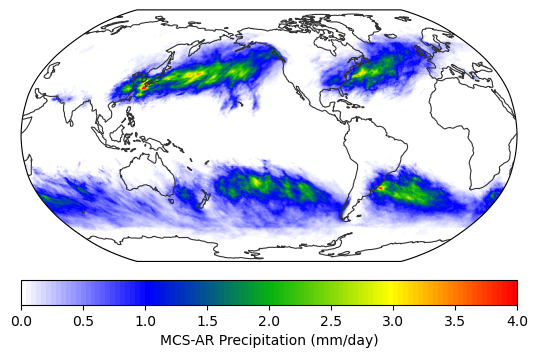

In [23]:
im = egh.healpix_show(mcs_ar_pcp_all.sel(source='obs'), vmin=0, vmax=4, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='MCS-AR Precipitation (mm/day)')

<Figure size 640x480 with 0 Axes>

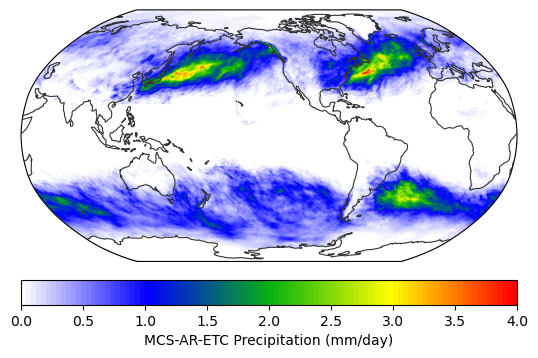

In [24]:
im = egh.healpix_show(mcs_ar_etc_pcp_all.sel(source='obs'), vmin=0, vmax=4, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='MCS-AR-ETC Precipitation (mm/day)')

## Filter data by latitude bands

In [25]:
tropics_lat = [-20, 20]
# extratropics_lat = [-90, -20, 20, 90]
tc_lat = [-40, 40]

tot_pcp_all_trop = tot_pcp_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
tot_pcp_all_extrop = tot_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

# Filter features for different latitude bands
# Original features
mcs_freq_all_trop = mcs_freq_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
mcs_pcp_all_trop = mcs_pcp_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
mcs_pcp_all_extrop = mcs_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

tc_freq_all_trop = tc_freq_all.where((hp_lat >= min(tc_lat)) & (hp_lat <= max(tc_lat)))
tc_pcp_all_trop = tc_pcp_all.where((hp_lat >= min(tc_lat)) & (hp_lat <= max(tc_lat)))

# Isolated features only
mcs_iso_freq_all_trop = mcs_iso_freq_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
mcs_iso_pcp_all_trop = mcs_iso_pcp_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
mcs_iso_pcp_all_extrop = mcs_iso_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

ar_iso_freq_all_extrop = ar_iso_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
ar_iso_pcp_all_extrop = ar_iso_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

etc_iso_freq_all_extrop = etc_iso_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
etc_iso_pcp_all_extrop = etc_iso_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

# Co-occurrence features
mcs_ar_freq_all_extrop = mcs_ar_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
mcs_ar_pcp_all_extrop = mcs_ar_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
mcs_ar_pcpfrac_all_extrop = mcs_ar_pcpfrac_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

mcs_etc_freq_all_extrop = mcs_etc_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
mcs_etc_pcp_all_extrop = mcs_etc_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
mcs_etc_pcpfrac_all_extrop = mcs_etc_pcpfrac_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

ar_etc_freq_all_extrop = ar_etc_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
ar_etc_pcp_all_extrop = ar_etc_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
ar_etc_pcpfrac_all_extrop = ar_etc_pcpfrac_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

mcs_ar_etc_freq_all_extrop = mcs_ar_etc_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
mcs_ar_etc_pcp_all_extrop = mcs_ar_etc_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
mcs_ar_etc_pcpfrac_all_extrop = mcs_ar_etc_pcpfrac_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

<Figure size 640x480 with 0 Axes>

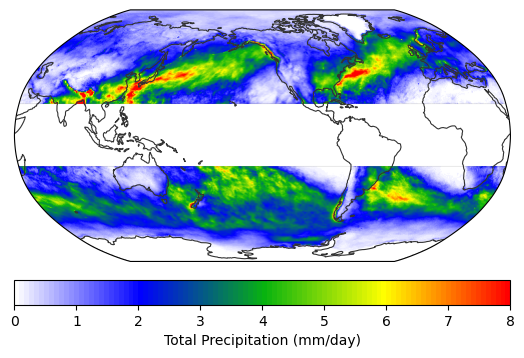

In [26]:
# im = egh.healpix_show(tot_pcp_all_trop.sel(source='obs'), vmin=0, vmax=12, cmap=cmaps.WhBlGrYeRe)
im = egh.healpix_show(tot_pcp_all_extrop.sel(source='obs'), vmin=0, vmax=8, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Total Precipitation (mm/day)')

<Figure size 640x480 with 0 Axes>

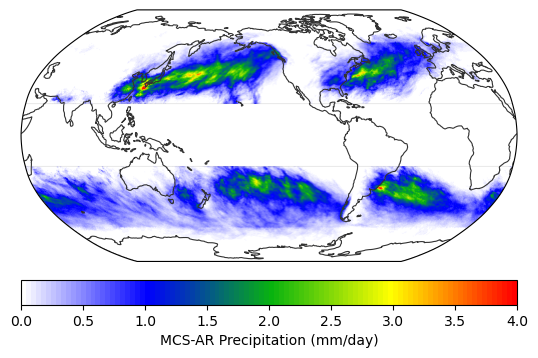

In [27]:
im = egh.healpix_show(mcs_ar_pcp_all_extrop.sel(source='obs'), vmin=0, vmax=4, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='MCS-AR Precipitation (mm/day)')

<Figure size 640x480 with 0 Axes>

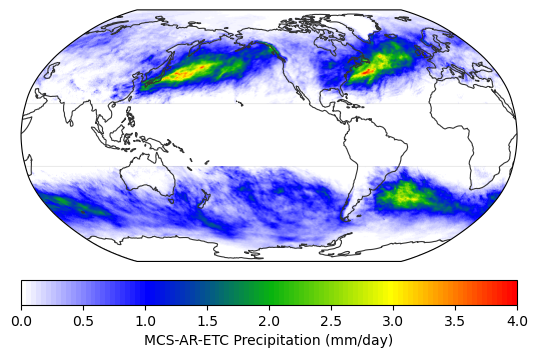

In [28]:
im = egh.healpix_show(mcs_ar_etc_pcp_all_extrop.sel(source='obs'), vmin=0, vmax=4, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='MCS-AR-ETC Precipitation (mm/day)')

In [29]:
# Compute global mean values
# Original features
mcs_freq_all_trop_avg = mcs_freq_all_trop.mean(dim='cell').compute()
mcs_pcp_all_avg = mcs_pcp_all.mean(dim='cell').compute()
mcs_pcp_all_trop_avg = mcs_pcp_all_trop.mean(dim='cell').compute()
mcs_pcp_all_extrop_avg = mcs_pcp_all_extrop.mean(dim='cell').compute()

tc_freq_all_trop_avg = tc_freq_all_trop.mean(dim='cell').compute()
tc_pcp_all_trop_avg = tc_pcp_all_trop.mean(dim='cell').compute()

# Isolated features only
mcs_iso_freq_all_trop_avg = mcs_iso_freq_all_trop.mean(dim='cell').compute()
mcs_iso_pcp_all_trop_avg = mcs_iso_pcp_all_trop.mean(dim='cell').compute()
mcs_iso_pcp_all_extrop_avg = mcs_iso_pcp_all_extrop.mean(dim='cell').compute()

ar_iso_freq_all_extrop_avg = ar_iso_freq_all_extrop.mean(dim='cell').compute()
ar_iso_pcp_all_extrop_avg = ar_iso_pcp_all_extrop.mean(dim='cell').compute()

etc_iso_freq_all_extrop_avg = etc_iso_freq_all_extrop.mean(dim='cell').compute()
etc_iso_pcp_all_extrop_avg = etc_iso_pcp_all_extrop.mean(dim='cell').compute()

# Co-occurrence features
mcs_ar_freq_all_extrop_avg = mcs_ar_freq_all_extrop.mean(dim='cell').compute()
mcs_ar_pcp_all_extrop_avg = mcs_ar_pcp_all_extrop.mean(dim='cell').compute()

mcs_etc_freq_all_extrop_avg = mcs_etc_freq_all_extrop.mean(dim='cell').compute()
mcs_etc_pcp_all_extrop_avg = mcs_etc_pcp_all_extrop.mean(dim='cell').compute()

ar_etc_freq_all_extrop_avg = ar_etc_freq_all_extrop.mean(dim='cell').compute()
ar_etc_pcp_all_extrop_avg = ar_etc_pcp_all_extrop.mean(dim='cell').compute()

mcs_ar_etc_freq_all_extrop_avg = mcs_ar_etc_freq_all_extrop.mean(dim='cell').compute()
mcs_ar_etc_pcp_all_extrop_avg = mcs_ar_etc_pcp_all_extrop.mean(dim='cell').compute()

In [30]:
# All MCS precipitation fractions
mcs_pcpfrac_all_avg = 100 * (mcs_pcp_all.sum(dim='cell') / tot_pcp_all.sum(dim='cell')).compute()
mcs_pcpfrac_all_trop_avg = 100 * (mcs_pcp_all_trop.sum(dim='cell') / tot_pcp_all_trop.sum(dim='cell')).compute()
mcs_pcpfrac_all_extrop_avg = 100 * (mcs_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()

# Extratropics isolated & co-occurring MCS precipitation fractions
mcs_iso_pcpfrac_all_extrop_avg = 100 * (mcs_iso_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()
mcs_ar_pcpfrac_all_extrop_avg = 100 * (mcs_ar_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()
mcs_etc_pcpfrac_all_extrop_avg = 100 * (mcs_etc_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()
mcs_ar_etc_pcpfrac_all_extrop_avg = 100 * (mcs_ar_etc_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()

ar_etc_pcpfrac_all_extrop_avg = 100 * (ar_etc_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()

In [35]:
# Total number of precipitation types
# Isolated features only
total_iso_pcp_all = mcs_iso_pcp_all + ar_iso_pcp_all + etc_iso_pcp_all + tc_pcp_all
# Co-occurrence features
total_cof_pcp_all = mcs_ar_pcp_all + ar_etc_pcp_all + mcs_etc_pcp_all + mcs_ar_etc_pcp_all
# All features
total_feature_pcp_all = total_iso_pcp_all + total_cof_pcp_all
# Residual precipitation not accounted for by identified features
res_pcp_all = tot_pcp_all - total_iso_pcp_all - total_cof_pcp_all

# Precipitation fractions
res_pcpfrac_all = 100. * res_pcp_all / tot_pcp_all
total_feature_pcpfrac_all = 100. * total_feature_pcp_all / tot_pcp_all

In [32]:
# mcs_iso_pcpfrac_all, ar_iso_pcpfrac_all, etc_iso_pcpfrac_all, tc_pcpfrac_all, 
# mcs_ar_pcpfrac_all, ar_etc_pcpfrac_all, mcs_etc_pcpfrac_all, mcs_ar_etc_pcpfrac_all, re_pcpfrac_all

# mcs_iso_pcp_all, ar_iso_pcp_all, etc_iso_pcp_all, tc_pcp_all, 
# mcs_ar_pcp_all, ar_etc_pcp_all, mcs_etc_pcp_all, mcs_ar_etc_pcp_all, res_pcp_all.

In [36]:
total_iso_pcpfrac_all = mcs_iso_pcpfrac_all + ar_iso_pcpfrac_all + etc_iso_pcpfrac_all + tc_pcpfrac_all
total_cof_pcpfrac_all = mcs_ar_pcpfrac_all + ar_etc_pcpfrac_all + mcs_etc_pcpfrac_all + mcs_ar_etc_pcpfrac_all

total_sum_pcpfrac_all = total_iso_pcpfrac_all + total_cof_pcpfrac_all + res_pcpfrac_all

<Figure size 640x480 with 0 Axes>

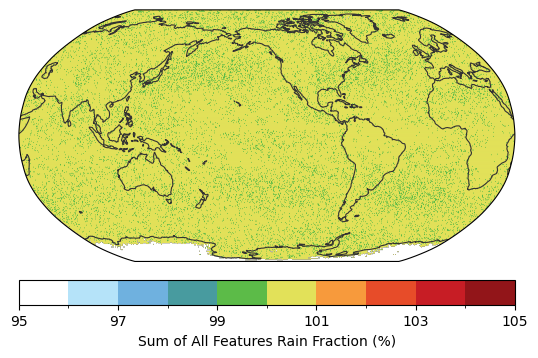

In [37]:
colormaps = cmaps.WhiteBlueGreenYellowRed
# colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
levels = np.arange(95, 105.1, 1)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(total_sum_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='Sum of All Features Rain Fraction (%)')

<Figure size 640x480 with 0 Axes>

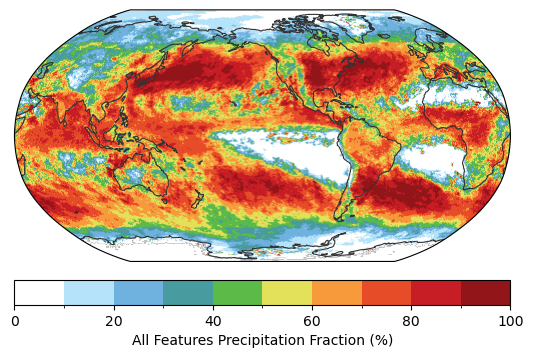

In [39]:
colormaps = cmaps.WhiteBlueGreenYellowRed
# colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
levels = np.arange(0, 100.1, 10)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(total_feature_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='All Features Precipitation Fraction (%)')

<Figure size 640x480 with 0 Axes>

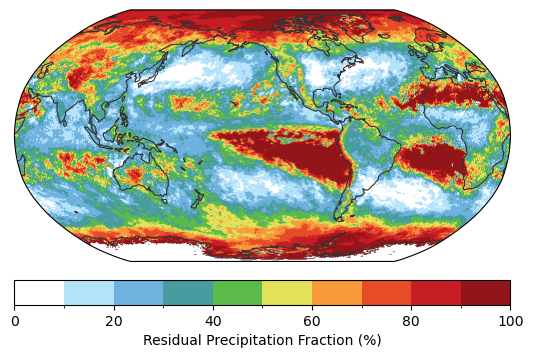

In [40]:
img = egh.healpix_show(re_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='Residual Precipitation Fraction (%)')

In [45]:
def get_ranked_precip_types(pcpfrac_dict, source_name, top_n=3):
    """
    Identify the top N dominant precipitation types for each grid cell.
    
    Parameters:
    -----------
    pcpfrac_dict : dict
        Dictionary where keys are precipitation type names and values are 
        xarray.DataArrays with dimensions (source, cell)
    source_name : str
        Name of the source to process (e.g., 'obs', 'm1', 'm2', etc.)
    top_n : int
        Number of top precipitation types to return (default: 3)
    
    Returns:
    --------
    ranked_types : dict
        Dictionary with keys 'rank_1', 'rank_2', 'rank_3', etc., each containing
        an xarray.DataArray with dimensions (cell,) with values 1-9 indicating 
        the precipitation type at that rank
    ranked_values : dict
        Dictionary with keys 'rank_1', 'rank_2', 'rank_3', etc., each containing
        an xarray.DataArray with the actual precipitation fraction values
    """
    
    # Define the precipitation types and their assigned values
    precip_types = {
        'mcs_iso_pcpfrac_all': 1,
        'ar_iso_pcpfrac_all': 2,
        'etc_iso_pcpfrac_all': 3,
        'tc_pcpfrac_all': 4,
        'mcs_ar_pcpfrac_all': 5,
        'ar_etc_pcpfrac_all': 6,
        'mcs_etc_pcpfrac_all': 7,
        'mcs_ar_etc_pcpfrac_all': 8,
        'res_pcpfrac_all': 9
    }
    
    # Stack all precipitation fractions into a single array
    # Shape will be (n_types, n_cells)
    pcpfrac_stack = []
    type_values = []
    
    for ptype, value in precip_types.items():
        if ptype in pcpfrac_dict:
            # Select data for the specified source
            data = pcpfrac_dict[ptype].sel(source=source_name)
            pcpfrac_stack.append(data.values)
            type_values.append(value)
        else:
            print(f"Warning: {ptype} not found in input dictionary")
    
    # Convert to numpy array: shape (n_types, n_cells)
    pcpfrac_array = np.array(pcpfrac_stack)
    type_values_array = np.array(type_values)
    
    # Get indices that would sort the array in descending order
    # argsort returns ascending, so we negate to get descending
    sorted_indices = np.argsort(-pcpfrac_array, axis=0)
    
    # Create output dictionaries
    ranked_types = {}
    ranked_values = {}
    
    # Get coordinates from first precipitation type for creating DataArrays
    first_key = list(precip_types.keys())[0]
    cell_coord = pcpfrac_dict[first_key].cell
    
    # Extract top N ranks
    for rank in range(top_n):
        rank_key = f'rank_{rank+1}'
        
        # Get indices for this rank
        rank_indices = sorted_indices[rank, :]
        
        # Map indices to precipitation type values
        ranked_type_values = type_values_array[rank_indices]
        
        # Get the actual precipitation fraction values for this rank
        # Use advanced indexing to get values
        ranked_pcp_values = pcpfrac_array[rank_indices, np.arange(pcpfrac_array.shape[1])]
        
        # Create DataArrays
        ranked_types[rank_key] = xr.DataArray(
            ranked_type_values,
            dims=['cell'],
            coords={'cell': cell_coord},
            attrs={
                'long_name': f'Rank {rank+1} precipitation type',
                'description': '1=MCS_iso, 2=AR_iso, 3=ETC_iso, 4=TC, 5=MCS_AR, 6=AR_ETC, 7=MCS_ETC, 8=MCS_AR_ETC, 9=Residual',
                'source': source_name,
                'rank': rank+1
            }
        )
        
        ranked_values[rank_key] = xr.DataArray(
            ranked_pcp_values,
            dims=['cell'],
            coords={'cell': cell_coord},
            attrs={
                'long_name': f'Rank {rank+1} precipitation fraction',
                'units': 'fraction',
                'source': source_name,
                'rank': rank+1
            }
        )
    
    return ranked_types, ranked_values


def get_all_sources_ranked_types(pcpfrac_dict, top_n=3):
    """
    Get ranked precipitation types for all sources.
    
    Parameters:
    -----------
    pcpfrac_dict : dict
        Dictionary where keys are precipitation type names and values are 
        xarray.DataArrays with dimensions (source, cell)
    top_n : int
        Number of top precipitation types to return (default: 3)
    
    Returns:
    --------
    ranked_types_all : dict
        Dictionary with keys 'rank_1', 'rank_2', 'rank_3', etc., each containing
        an xarray.DataArray with dimensions (source, cell)
    ranked_values_all : dict
        Dictionary with keys 'rank_1', 'rank_2', 'rank_3', etc., each containing
        an xarray.DataArray with the actual precipitation fraction values
    """
    
    # Get list of sources from the first precipitation type
    first_key = list(pcpfrac_dict.keys())[0]
    sources = pcpfrac_dict[first_key].source.values
    
    # Initialize output dictionaries
    ranked_types_all = {f'rank_{i+1}': [] for i in range(top_n)}
    ranked_values_all = {f'rank_{i+1}': [] for i in range(top_n)}
    
    # Calculate ranked types for each source
    for source in sources:
        ranked_types, ranked_values = get_ranked_precip_types(pcpfrac_dict, source, top_n)
        
        for rank_key in ranked_types.keys():
            ranked_types_all[rank_key].append(ranked_types[rank_key])
            ranked_values_all[rank_key].append(ranked_values[rank_key])
    
    # Concatenate into DataArrays with source dimension
    for rank_key in ranked_types_all.keys():
        ranked_types_all[rank_key] = xr.concat(ranked_types_all[rank_key], dim='source')
        ranked_types_all[rank_key]['source'] = sources
        
        ranked_values_all[rank_key] = xr.concat(ranked_values_all[rank_key], dim='source')
        ranked_values_all[rank_key]['source'] = sources
    
    return ranked_types_all, ranked_values_all

In [ ]:
# Usage example:
# Prepare the dictionary with your data
pcpfrac_dict = {
    'mcs_iso_pcpfrac_all': mcs_iso_pcpfrac_all,
    'ar_iso_pcpfrac_all': ar_iso_pcpfrac_all,
    'etc_iso_pcpfrac_all': etc_iso_pcpfrac_all,
    'tc_pcpfrac_all': tc_pcpfrac_all,
    'mcs_ar_pcpfrac_all': mcs_ar_pcpfrac_all,
    'ar_etc_pcpfrac_all': ar_etc_pcpfrac_all,
    'mcs_etc_pcpfrac_all': mcs_etc_pcpfrac_all,
    'mcs_ar_etc_pcpfrac_all': mcs_ar_etc_pcpfrac_all,
    'res_pcpfrac_all': res_pcpfrac_all
}

# Get ranked types for all sources (top 3)
ranked_types_all, ranked_values_all = get_all_sources_ranked_types(pcpfrac_dict, top_n=3)

# Access individual ranks
dominant_types_all = ranked_types_all['rank_1']  # 1st place
second_types_all = ranked_types_all['rank_2']    # 2nd place
third_types_all = ranked_types_all['rank_3']     # 3rd place

# Also get the actual precipitation fraction values for each rank
dominant_values_all = ranked_values_all['rank_1']
second_values_all = ranked_values_all['rank_2']
third_values_all = ranked_values_all['rank_3']

# Or get for a specific source
ranked_types_obs, ranked_values_obs = get_ranked_precip_types(pcpfrac_dict, 'obs', top_n=3)


# Plotting function for ranked types
def plot_ranked_precip_type(ranked_data, rank_num, source_name, figname=None):
    """
    Plot map of ranked precipitation type.
    
    Parameters:
    -----------
    ranked_data : xarray.DataArray
        DataArray containing precipitation type values (1-9)
    rank_num : int
        Rank number (1, 2, or 3)
    source_name : str
        Source name for the title
    figname : str, optional
        Filename to save the figure
    """
    from matplotlib.colors import ListedColormap, BoundaryNorm
    
    # Define colors for each precipitation type
    precip_colors = [
        '#1f77b4',  # 1: MCS_iso - blue
        '#ff7f0e',  # 2: AR_iso - orange
        '#2ca02c',  # 3: ETC_iso - green
        '#d62728',  # 4: TC - red
        '#9467bd',  # 5: MCS_AR - purple
        '#8c564b',  # 6: AR_ETC - brown
        '#e377c2',  # 7: MCS_ETC - pink
        '#7f7f7f',  # 8: MCS_AR_ETC - gray
        '#bcbd22',  # 9: Residual - yellow-green
    ]
    
    precip_cmap = ListedColormap(precip_colors)
    precip_norm = BoundaryNorm(boundaries=np.arange(0.5, 10.5, 1), ncolors=9)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(15, 8), 
                           subplot_kw={'projection': ccrs.Robinson(central_longitude=225)})
    ax.set_global()
    ax.add_feature(cf.NaturalEarthFeature('physical', 'land', '110m'), 
                   facecolor='none', edgecolor='k', zorder=3)
    
    # Plot data
    im = egh.healpix_show(ranked_data, ax=ax, cmap=precip_cmap, norm=precip_norm, zorder=2)
    
    # Add colorbar with labels
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, 
                        ticks=np.arange(1, 10), shrink=0.8)
    cbar.set_label(f'Rank {rank_num} Precipitation Type', fontsize=12)
    cbar.ax.set_xticklabels(['MCS_iso', 'AR_iso', 'ETC_iso', 'TC', 'MCS_AR', 
                             'AR_ETC', 'MCS_ETC', 'MCS_AR_ETC', 'Residual'], 
                            rotation=45, ha='right', fontsize=10)
    
    # Add title
    rank_suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(rank_num, 'th')
    ax.set_title(f'{rank_num}{rank_suffix} Ranked Precipitation Type - {source_name}', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    
    # Save figure if filename provided
    if figname:
        plt.savefig(figname, dpi=300, bbox_inches='tight')
        print(f'Figure saved: {figname}')
    
    plt.show()
    return fig, ax


# Example: Plot 1st, 2nd, and 3rd ranked types for OBS
plot_ranked_precip_type(ranked_types_obs['rank_1'], 1, 'OBS', 
                        figname=f'{figdir}rank1_precip_type_obs.png')
plot_ranked_precip_type(ranked_types_obs['rank_2'], 2, 'OBS', 
                        figname=f'{figdir}rank2_precip_type_obs.png')
plot_ranked_precip_type(ranked_types_obs['rank_3'], 3, 'OBS', 
                        figname=f'{figdir}rank3_precip_type_obs.png')

In [46]:
# Usage example:
# Prepare the dictionary with your data
pcpfrac_dict = {
    'mcs_iso_pcpfrac_all': mcs_iso_pcpfrac_all,
    'ar_iso_pcpfrac_all': ar_iso_pcpfrac_all,
    'etc_iso_pcpfrac_all': etc_iso_pcpfrac_all,
    'tc_pcpfrac_all': tc_pcpfrac_all,
    'mcs_ar_pcpfrac_all': mcs_ar_pcpfrac_all,
    'ar_etc_pcpfrac_all': ar_etc_pcpfrac_all,
    'mcs_etc_pcpfrac_all': mcs_etc_pcpfrac_all,
    'mcs_ar_etc_pcpfrac_all': mcs_ar_etc_pcpfrac_all,
    'res_pcpfrac_all': res_pcpfrac_all
}

# Get ranked types for all sources (top 3)
ranked_types_all, ranked_values_all = get_all_sources_ranked_types(pcpfrac_dict, top_n=3)

# Access individual ranks
dominant_types_all = ranked_types_all['rank_1']  # 1st place
second_types_all = ranked_types_all['rank_2']    # 2nd place
third_types_all = ranked_types_all['rank_3']     # 3rd place

# Also get the actual precipitation fraction values for each rank
dominant_values_all = ranked_values_all['rank_1']
second_values_all = ranked_values_all['rank_2']
third_values_all = ranked_values_all['rank_3']

# Or get for a specific source
ranked_types_obs, ranked_values_obs = get_ranked_precip_types(pcpfrac_dict, 'obs', top_n=3)

In [79]:
dominant_types_all

<xarray.DataArray (source: 5, cell: 786432)> Size: 31MB
array([[1, 1, 1, ..., 1, 1, 1],
       [9, 9, 9, ..., 9, 9, 9],
       [9, 9, 9, ..., 1, 1, 1],
       [1, 9, 9, ..., 1, 1, 1],
       [9, 9, 9, ..., 1, 9, 9]])
Coordinates:
  * cell     (cell) int32 3MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
  * source   (source) <U3 60B 'obs' 'm1' 'm2' 'm3' 'm4'
Attributes:
    long_name:    Rank 1 precipitation type
    description:  1=MCS_iso, 2=AR_iso, 3=ETC_iso, 4=TC, 5=MCS_AR, 6=AR_ETC, 7...
    source:       obs
    rank:         1

In [60]:
# # Plotting function for ranked types
# def plot_ranked_precip_type(ranked_data, rank_num, source_name, figname=None, lat_range=(-60, 60)):
#     """
#     Plot map of ranked precipitation type.
    
#     Parameters:
#     -----------
#     ranked_data : xarray.DataArray
#         DataArray containing precipitation type values (1-9)
#     rank_num : int
#         Rank number (1, 2, or 3)
#     source_name : str
#         Source name for the title
#     figname : str, optional
#         Filename to save the figure
#     """
#     from matplotlib.colors import ListedColormap, BoundaryNorm
    
#     # # Define colors for each precipitation type
#     # precip_colors = [
#     #     '#1f77b4',  # 1: MCS_iso - blue
#     #     '#ff7f0e',  # 2: AR_iso - orange
#     #     '#2ca02c',  # 3: ETC_iso - green
#     #     '#d62728',  # 4: TC - red
#     #     '#9467bd',  # 5: MCS_AR - purple
#     #     '#8c564b',  # 6: AR_ETC - brown
#     #     '#e377c2',  # 7: MCS_ETC - pink
#     #     '#7f7f7f',  # 8: MCS_AR_ETC - gray
#     #     '#bcbd22',  # 9: Residual - yellow-green
#     # ]

#     # # Define colors for each precipitation type with visual hierarchy
#     # precip_colors = [
#     #     '#1f77b4',  # 1: MCS_iso - blue (keep same)
#     #     '#ff7f0e',  # 2: AR_iso - orange (keep same)
#     #     '#2ca02c',  # 3: ETC_iso - green (keep same)
#     #     '#d62728',  # 4: TC - red (keep same)
#     #     '#8B0A50',  # 5: MCS_AR - dark magenta/burgundy (prominent, 2nd most)
#     #     '#C8A2C8',  # 6: AR_ETC - light lavender (least prominent of co-occurrences)
#     #     '#B8336A',  # 7: MCS_ETC - medium rose/magenta (3rd most prominent)
#     #     '#6B0848',  # 8: MCS_AR_ETC - very dark magenta/purple (most prominent)
#     #     '#D3D3D3',  # 9: Residual - light gray (less prominent, distinct)
#     # ]

#     # Define colors for each precipitation type with visual hierarchy
#     precip_colors = [
#         "#DCD91C",  # 1: MCS_iso - blue (keep same)
#         "#11008d",  # 2: AR_iso - orange (keep same)
#         "#19a519",  # 3: ETC_iso - green (keep same)
#         '#d62728',  # 4: TC - red (keep same)
#         "#059D96",  # 5: MCS_AR - dark magenta/burgundy (prominent, 2nd most)
#         '#C8A2C8',  # 6: AR_ETC - light lavender (least prominent of co-occurrences)
#         "#6332C4",  # 7: MCS_ETC - medium rose/magenta (3rd most prominent)
#         "#044F9A",  # 8: MCS_AR_ETC - very dark magenta/purple (most prominent)
#         "#D3D3D39F",  # 9: Residual - light gray (less prominent, distinct)
#     ]
    
#     precip_cmap = ListedColormap(precip_colors)
#     precip_norm = BoundaryNorm(boundaries=np.arange(0.5, 10.5, 1), ncolors=9)

#     # Create figure with Robinson projection
#     proj = ccrs.Robinson(central_longitude=225)
#     data_proj = ccrs.PlateCarree()
    
#     # Create figure
#     fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={'projection': proj})

#     # ax.set_global()
#     ax.set_extent([0, 360, lat_range[0], lat_range[1]], crs=data_proj)
#     # Add map features
#     ax.add_feature(cf.NaturalEarthFeature('physical', 'land', '110m'), 
#                    facecolor='none', edgecolor='k', zorder=3)
#     # ax.set_aspect('auto', adjustable=None)
    
#     # Plot data
#     im = egh.healpix_show(ranked_data, ax=ax, cmap=precip_cmap, norm=precip_norm, zorder=2)
    
#     # Add colorbar with labels
#     cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, 
#                         ticks=np.arange(1, 10), shrink=0.8)
#     cbar.set_label(f'Rank {rank_num} Precipitation Type', fontsize=12)
#     cbar.ax.set_xticklabels(['MCS_iso', 'AR_iso', 'ETC_iso', 'TC', 'MCS_AR', 
#                              'AR_ETC', 'MCS_ETC', 'MCS_AR_ETC', 'Residual'], 
#                             rotation=45, ha='right', fontsize=10)
    
#     # Add title
#     rank_suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(rank_num, 'th')
#     ax.set_title(f'{rank_num}{rank_suffix} Ranked Precipitation Type - {source_name}', 
#                  fontsize=14, fontweight='bold')
    
#     plt.tight_layout()
    
#     # Save figure if filename provided
#     if figname:
#         plt.savefig(figname, dpi=300, bbox_inches='tight')
#         print(f'Figure saved: {figname}')
    
#     plt.show()
#     return fig, ax

In [63]:
def plot_ranked_precip_type(ranked_data, rank_num, source_name, figname=None, lat_range=(-60, 60)):
    """
    Plot map of ranked precipitation type.
    
    Parameters:
    -----------
    ranked_data : xarray.DataArray
        DataArray containing precipitation type values (1-9)
    rank_num : int
        Rank number (1, 2, or 3)
    source_name : str
        Source name for the title
    figname : str, optional
        Filename to save the figure
    lat_range : tuple, optional
        Latitude range to display (min_lat, max_lat). Default: (-60, 60)
    """
    from matplotlib.colors import ListedColormap, BoundaryNorm
    
    # Define colors for each precipitation type with visual hierarchy
    precip_colors = [
        "#DCD91C",  # 1: MCS_iso - blue (keep same)
        "#11008d",  # 2: AR_iso - orange (keep same)
        "#19a519",  # 3: ETC_iso - green (keep same)
        '#d62728',  # 4: TC - red (keep same)
        "#059D96",  # 5: MCS_AR - dark magenta/burgundy (prominent, 2nd most)
        '#C8A2C8',  # 6: AR_ETC - light lavender (least prominent of co-occurrences)
        "#6332C4",  # 7: MCS_ETC - medium rose/magenta (3rd most prominent)
        "#044F9A",  # 8: MCS_AR_ETC - very dark magenta/purple (most prominent)
        "#D3D3D39F",  # 9: Residual - light gray (less prominent, distinct)
    ]
    
    precip_cmap = ListedColormap(precip_colors)
    precip_norm = BoundaryNorm(boundaries=np.arange(0.5, 10.5, 1), ncolors=9)
    
    # Create figure with Robinson projection
    proj = ccrs.Robinson(central_longitude=225)
    data_proj = ccrs.PlateCarree()
    
    fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={'projection': proj})
    
    # Set global extent to keep the curved Earth appearance
    ax.set_global()
    
    # Add map features
    ax.add_feature(cf.NaturalEarthFeature('physical', 'land', '110m'), 
                   facecolor='none', edgecolor='k', zorder=3)
    ax.set_aspect('auto', adjustable=None)
    
    # Add gridlines
    gl = ax.gridlines(crs=data_proj, draw_labels=False, linestyle='--', linewidth=0.5)
    
    # Mask data outside the latitude range
    # Get lat coordinates from the data
    if hasattr(ranked_data, 'lat'):
        lat_coord = ranked_data.lat
    else:
        # If lat is not a coordinate, try to get it from the healpix grid
        lat_coord = hp_lat  # Assuming hp_lat is available from earlier in your notebook
    
    # Create mask for latitude range
    lat_mask = (lat_coord >= lat_range[0]) & (lat_coord <= lat_range[1])
    
    # Apply mask to data
    masked_data = ranked_data.where(lat_mask)
    
    # Plot data
    im = egh.healpix_show(masked_data, ax=ax, cmap=precip_cmap, norm=precip_norm, zorder=2)
    
    # # Optionally add latitude boundary lines to show the cutoff
    # if lat_range[0] > -90 or lat_range[1] < 90:
    #     for lat in [lat_range[0], lat_range[1]]:
    #         lons = np.linspace(-180, 180, 361)
    #         lats = np.full_like(lons, lat)
    #         ax.plot(lons, lats, color='k', linestyle='--', linewidth=2, 
    #                transform=data_proj, zorder=4, alpha=0.8)
    
    # Add colorbar with labels
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, 
                        ticks=np.arange(1, 10), shrink=0.8)
    cbar.set_label(f'Rank {rank_num} Precipitation Type', fontsize=12, fontweight='bold')
    cbar.ax.set_xticklabels(['MCS_iso', 'AR_iso', 'ETC_iso', 'TC', 'MCS_AR', 
                             'AR_ETC', 'MCS_ETC', 'MCS_AR_ETC', 'Residual'], 
                            rotation=45, ha='right', fontsize=10)
    
    # Add title
    rank_suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(rank_num, 'th')
    title_lat_info = f' ({lat_range[0]}°S to {lat_range[1]}°N)' if lat_range != (-90, 90) else ''
    ax.set_title(f'{rank_num}{rank_suffix} Ranked Precipitation Type - {source_name}{title_lat_info}', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    
    # Save figure if filename provided
    if figname:
        plt.savefig(figname, dpi=300, bbox_inches='tight')
        print(f'Figure saved: {figname}')
    
    plt.show()
    return fig, ax

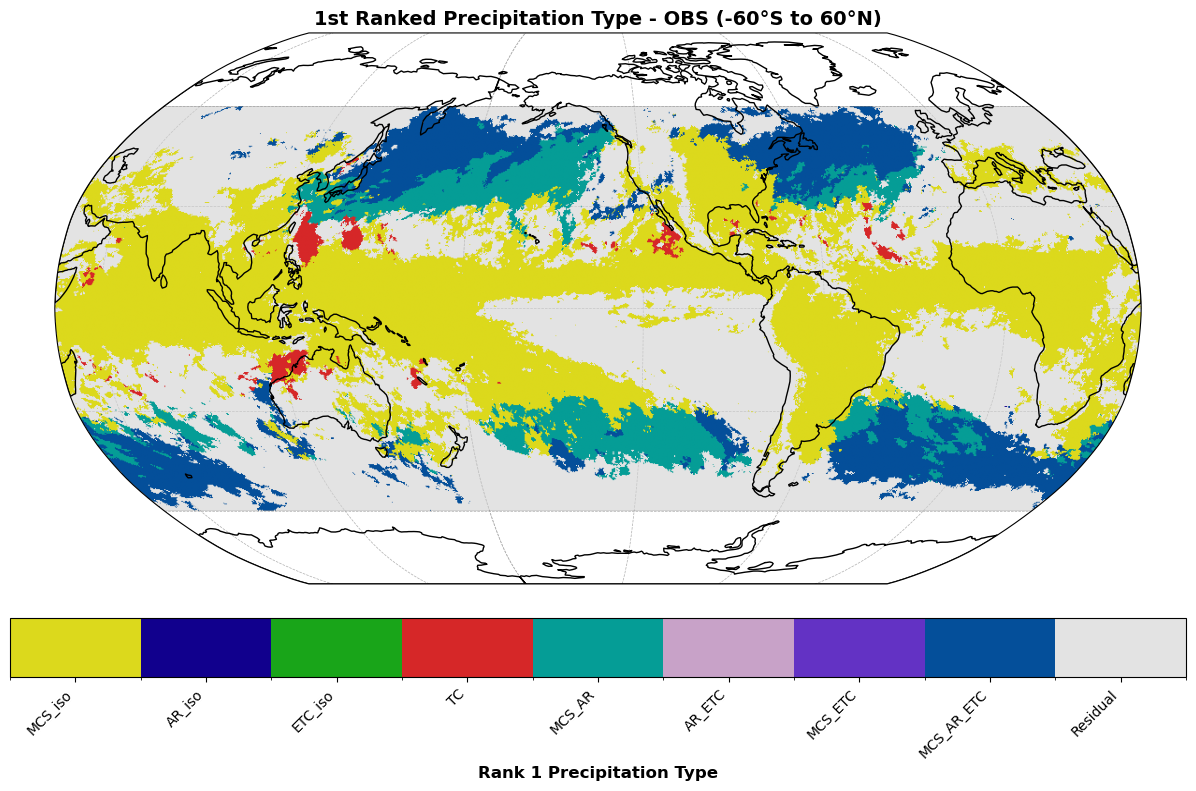

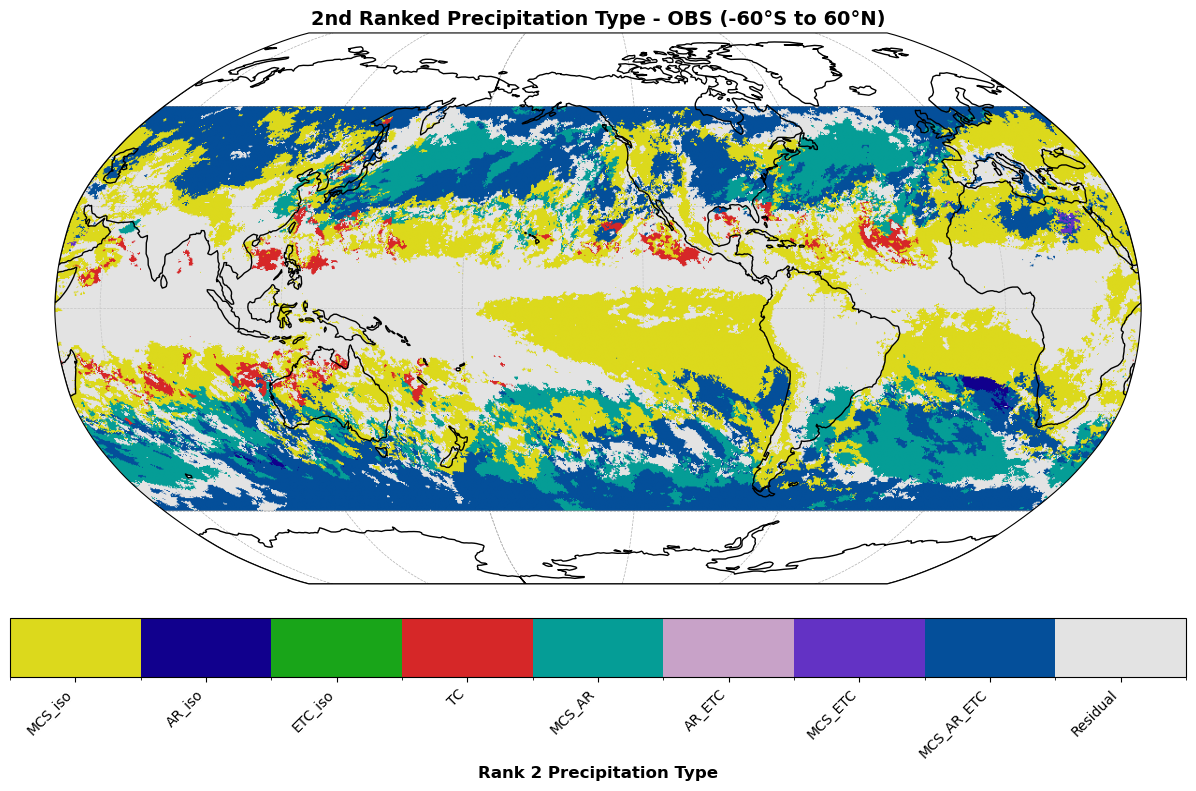

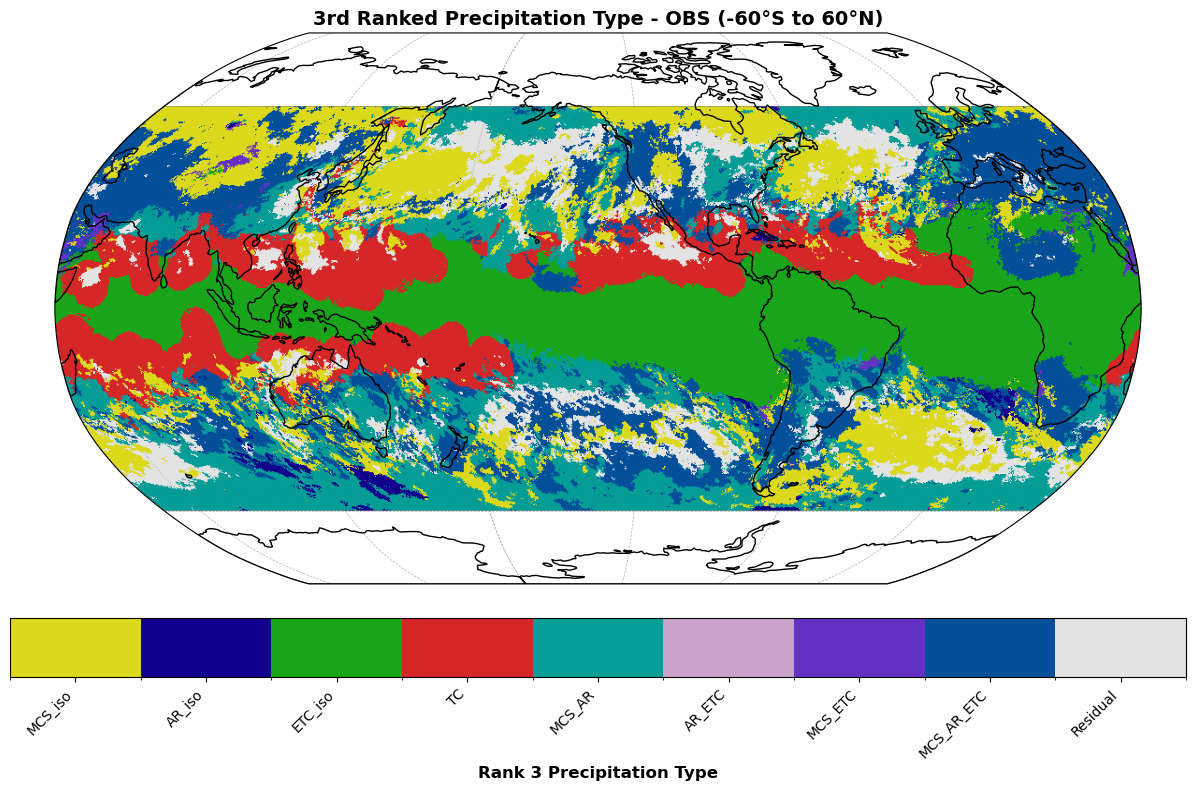

(<Figure size 1500x800 with 2 Axes>,
 <GeoAxes: title={'center': '3rd Ranked Precipitation Type - OBS (-60°S to 60°N)'}>)

In [64]:
# Example: Plot 1st, 2nd, and 3rd ranked types for OBS
plot_ranked_precip_type(ranked_types_obs['rank_1'], 1, 'OBS', )
                        # figname=f'{figdir}rank1_precip_type_obs.png')
plot_ranked_precip_type(ranked_types_obs['rank_2'], 2, 'OBS', )
                        # figname=f'{figdir}rank2_precip_type_obs.png')
plot_ranked_precip_type(ranked_types_obs['rank_3'], 3, 'OBS', )
                        # figname=f'{figdir}rank3_precip_type_obs.png')

## Function to plot multiple maps

In [65]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """
    Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [80]:
def plot_ranked_types_grid(da_list, titles, figname, 
                          min_thresh=None, wspace=None, hspace=None,
                          figsize=None, fontsize=None, cb_fontsize=None, 
                          show_gridlines=False, figtitle=None, dpi=200, 
                          lat_lines=None, lat_range=(-60, 60)):
    """
    Plot a grid of ranked precipitation type maps with custom discrete colormap
    
    Parameters:
    -----------
    da_list : list of lists
        2D list of xarray DataArrays to plot (ranked type data with values 1-9), 
        dimensions should be [nrow][ncol]
    titles : list of lists
        2D list of titles for each panel, dimensions should be [nrow][ncol]
    figname : str
        Output filename
    min_thresh : float, optional
        Minimum threshold for data display (not typically used for type data)
    wspace : float, optional
        Width space between subplots
    hspace : float, optional
        Height space between subplots
    figsize : tuple, optional
        Figure size (width, height)
    fontsize : int, optional
        Font size for labels
    cb_fontsize : int, optional
        Font size for colorbar labels
    show_gridlines : bool, optional
        Whether to show gridlines
    figtitle : str, optional
        Figure title
    dpi : int, optional
        Resolution for saved figure
    lat_lines : list, optional
        List of latitude values to plot as horizontal lines
    lat_range : tuple, optional
        Latitude range to display (min_lat, max_lat). Default: (-60, 60)
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure object
    """
    from matplotlib.colors import ListedColormap, BoundaryNorm
    
    # Define colors for each precipitation type with visual hierarchy
    precip_colors = [
        "#DCD91C",  # 1: MCS_iso - blue (keep same)
        "#11008d",  # 2: AR_iso - orange (keep same)
        "#19a519",  # 3: ETC_iso - green (keep same)
        '#d62728',  # 4: TC - red (keep same)
        "#059D96",  # 5: MCS_AR - dark magenta/burgundy (prominent, 2nd most)
        '#C8A2C8',  # 6: AR_ETC - light lavender (least prominent of co-occurrences)
        "#6332C4",  # 7: MCS_ETC - medium rose/magenta (3rd most prominent)
        "#044F9A",  # 8: MCS_AR_ETC - very dark magenta/purple (most prominent)
        "#D3D3D39F",  # 9: Residual - light gray (less prominent, distinct)
    ]
    
    precip_cmap = ListedColormap(precip_colors)
    precip_norm = BoundaryNorm(boundaries=np.arange(0.5, 10.5, 1), ncolors=9)
    
    # Get grid dimensions from input data
    nrow = len(da_list)
    ncol = len(da_list[0]) if nrow > 0 else 0
    
    # Handle case where parameters might be the same for all panels
    def ensure_grid_format(param, param_name):
        if not isinstance(param, list):
            # If single value provided, apply to all panels
            return [[param for _ in range(ncol)] for _ in range(nrow)]
        elif isinstance(param, list):
            if len(param) == 0:
                # Empty list
                return [[[] for _ in range(ncol)] for _ in range(nrow)]
            elif isinstance(param[0], list):
                # Already a list of lists, return as is
                return param
            else:
                # It's a 1D list, use same list for all panels
                return [[param for _ in range(ncol)] for _ in range(nrow)]
        return param
    
    # Ensure titles have proper grid format
    titles = ensure_grid_format(titles, "titles")
    
    mpl.rcParams['font.size'] = fontsize
    proj = ccrs.Robinson(central_longitude=225)
    data_proj = ccrs.PlateCarree()
    resolution = '110m'
    land = cf.NaturalEarthFeature('physical', 'land', resolution)

    fig = plt.figure(figsize=figsize, dpi=100)
    # Setup two columns (left: plots, right: colorbar)
    gs0 = gridspec.GridSpec(1, 2, figure=fig, height_ratios=[1], width_ratios=[1, 0.02], wspace=0.05)
    # Setup panels to the left
    h_ratios = list(np.repeat(1, nrow))
    w_ratios = list(np.repeat(1, ncol))
    gs = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs0[0], 
                                         height_ratios=h_ratios, width_ratios=w_ratios, 
                                         wspace=wspace, hspace=hspace)
    
    # Loop over each panel in the grid
    cf1 = None  # Will store the last plot for colorbar
    for row in range(nrow):
        for col in range(ncol):
            # Get panel index
            panel_idx = row * ncol + col

            # Get data for this panel
            Var = da_list[row][col]
            if Var is not None:
            
                # Create subplot
                ax = plt.subplot(gs[panel_idx], projection=proj)
                ax.set_global()
                ax.add_feature(land, facecolor='none', edgecolor='k', zorder=3)
                ax.set_aspect('auto', adjustable=None)
                
                # Add title
                flabel = ax.text(0.02, 0.94, titles[row][col], transform=ax.transAxes, fontsize=fontsize)
                flabel.set_bbox(dict(facecolor='w', alpha=0.8, edgecolor='w'))
                
                # Add gridlines
                if show_gridlines:
                    gl = ax.gridlines(crs=data_proj, draw_labels=False, linestyle='--', linewidth=0.5, zorder=10)
                
                # Mask data outside the latitude range if specified
                if lat_range is not None:
                    # Get lat coordinates from the data
                    if hasattr(Var, 'lat'):
                        lat_coord = Var.lat
                    else:
                        # If lat is not a coordinate, try to get it from the healpix grid
                        lat_coord = hp_lat  # Assuming hp_lat is available from earlier in your notebook
                    
                    # Create mask for latitude range
                    lat_mask = (lat_coord >= lat_range[0]) & (lat_coord <= lat_range[1])
                    
                    # Apply mask to data
                    Var = Var.where(lat_mask)
                
                # Apply minimum threshold if provided (unlikely for type data)
                if min_thresh is not None:
                    Var = Var.where(Var > min_thresh)
                
                # Plot data with discrete colormap
                cf1 = egh.healpix_show(Var, ax=ax, cmap=precip_cmap, norm=precip_norm, zorder=2)
                
                # Add latitude lines if specified
                if lat_lines is not None:
                    for lat in lat_lines:
                        # Create longitude array spanning the globe
                        lons = np.linspace(-180, 180, 361)
                        lats = np.full_like(lons, lat)
                        ax.plot(lons, lats, color='k', linestyle='--', linewidth=1.5, 
                            transform=data_proj, zorder=4, alpha=0.8)
    
    # Add colorbar (using the last plotted data)
    if cf1 is not None:
        cax = plt.subplot(gs0[1])
        cbar = plt.colorbar(cf1, cax=cax, label='', 
                           ticks=np.arange(1, 10), orientation='vertical', extend='neither')
        # Set custom tick labels
        cbar.ax.set_yticklabels(['MCS', 'AR', 'ETC', 'TC', 'MCS-AR', 
                                 'AR-ETC', 'MCS-ETC', 'MCS-AR-ETC', 'Residual'], 
                                fontsize=cb_fontsize)
    
    # Add suptitle
    if figtitle:
        fig.suptitle(figtitle, y=0.92, fontweight='bold', fontsize=fontsize+2)
    
    # Save figure
    fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
    print(f'Figure saved: {figname}')
    return fig

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/globalmap_precip_rank1_types_annual.png


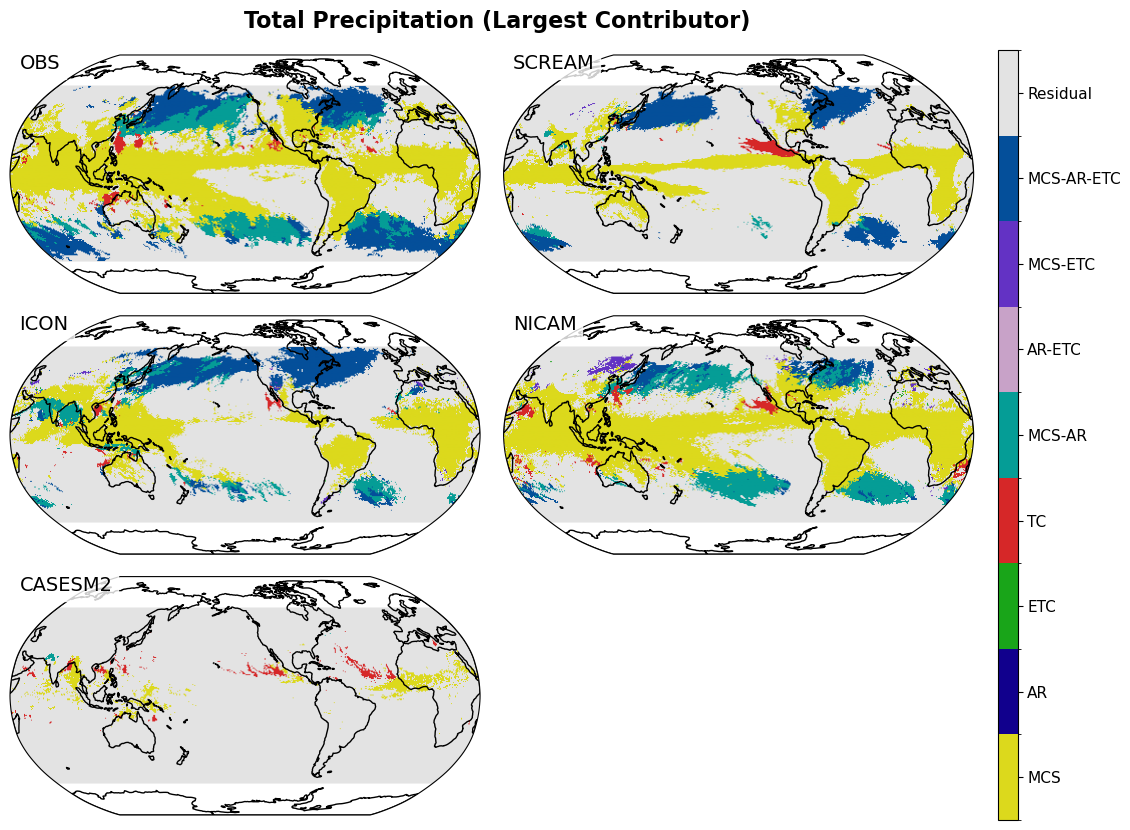

In [ ]:
# Prepare data as 2D list
sources = ['obs', 'm1', 'm2', 'm3', 'm4']
nrow = 3
ncol = 2

# Create 2D lists for data and titles
da_list = []
titles = []
row_data = []
row_titles = []

for i, src in enumerate(sources):
    row_data.append(dominant_types_all.sel(source=src))
    row_titles.append(name_map_plot[src])
    
    # Start new row after ncol panels
    if (i + 1) % ncol == 0 or i == len(sources) - 1:
        # Pad with None if needed for last row
        while len(row_data) < ncol:
            row_data.append(None)
            row_titles.append('')
        
        da_list.append(row_data)
        titles.append(row_titles)
        row_data = []
        row_titles = []

# Plot the grid
fig = plot_ranked_types_grid(
    da_list=da_list,
    titles=titles,
    figname=f'{figdir}globalmap_precip_rank1_types_annual.png',
    figsize=(13, 10),
    fontsize=14,
    cb_fontsize=11,
    wspace=0.05,
    hspace=0.05,
    show_gridlines=False,
    figtitle='Total Precipitation (Largest Contributor)',
    dpi=300,
    lat_range=(-60, 60)
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/globalmap_precip_rank2_types_annual.png


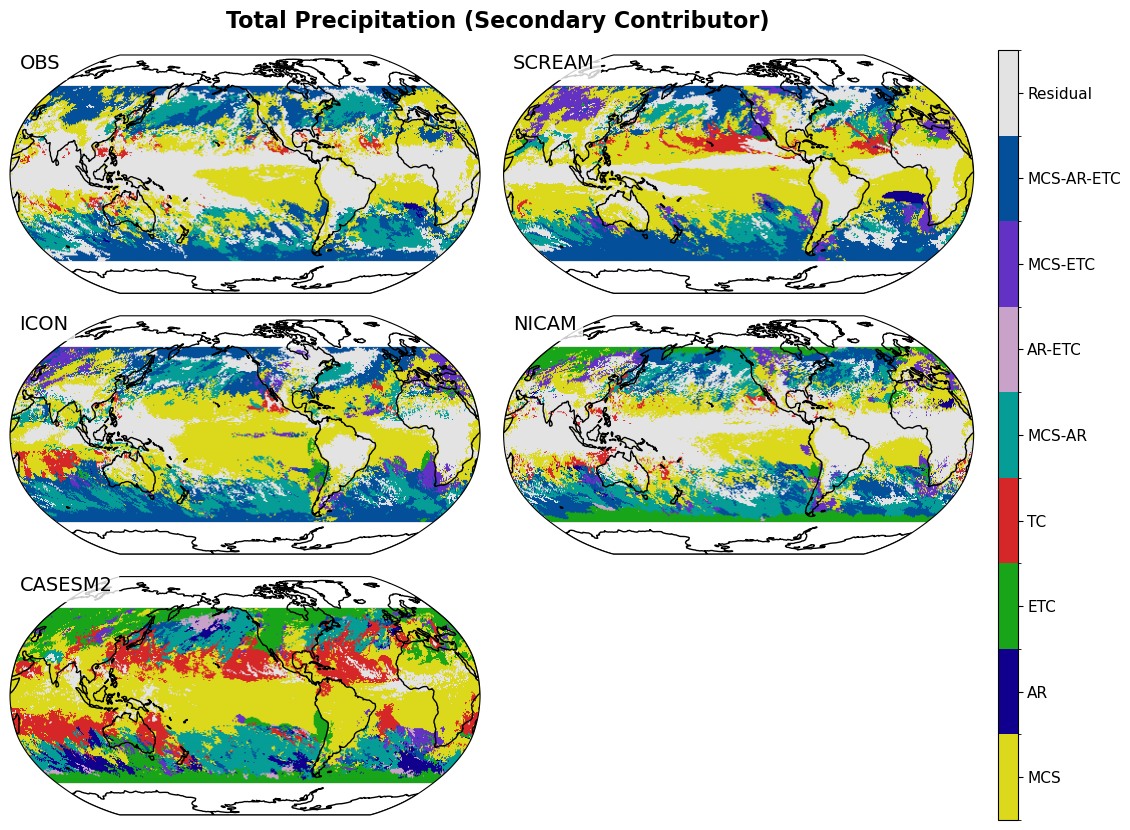

In [82]:
# Prepare data as 2D list
sources = ['obs', 'm1', 'm2', 'm3', 'm4']
nrow = 3
ncol = 2

# Create 2D lists for data and titles
da_list = []
titles = []
row_data = []
row_titles = []

for i, src in enumerate(sources):
    row_data.append(second_types_all.sel(source=src))
    row_titles.append(name_map_plot[src])
    
    # Start new row after ncol panels
    if (i + 1) % ncol == 0 or i == len(sources) - 1:
        # Pad with None if needed for last row
        while len(row_data) < ncol:
            row_data.append(None)
            row_titles.append('')
        
        da_list.append(row_data)
        titles.append(row_titles)
        row_data = []
        row_titles = []

# Plot the grid
fig = plot_ranked_types_grid(
    da_list=da_list,
    titles=titles,
    figname=f'{figdir}globalmap_precip_rank2_types_annual.png',
    figsize=(13, 10),
    fontsize=14,
    cb_fontsize=11,
    wspace=0.05,
    hspace=0.05,
    show_gridlines=False,
    figtitle='Total Precipitation (Secondary Contributor)',
    dpi=300,
    lat_range=(-60, 60)
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/globalmap_precip_rank3_types_annual.png


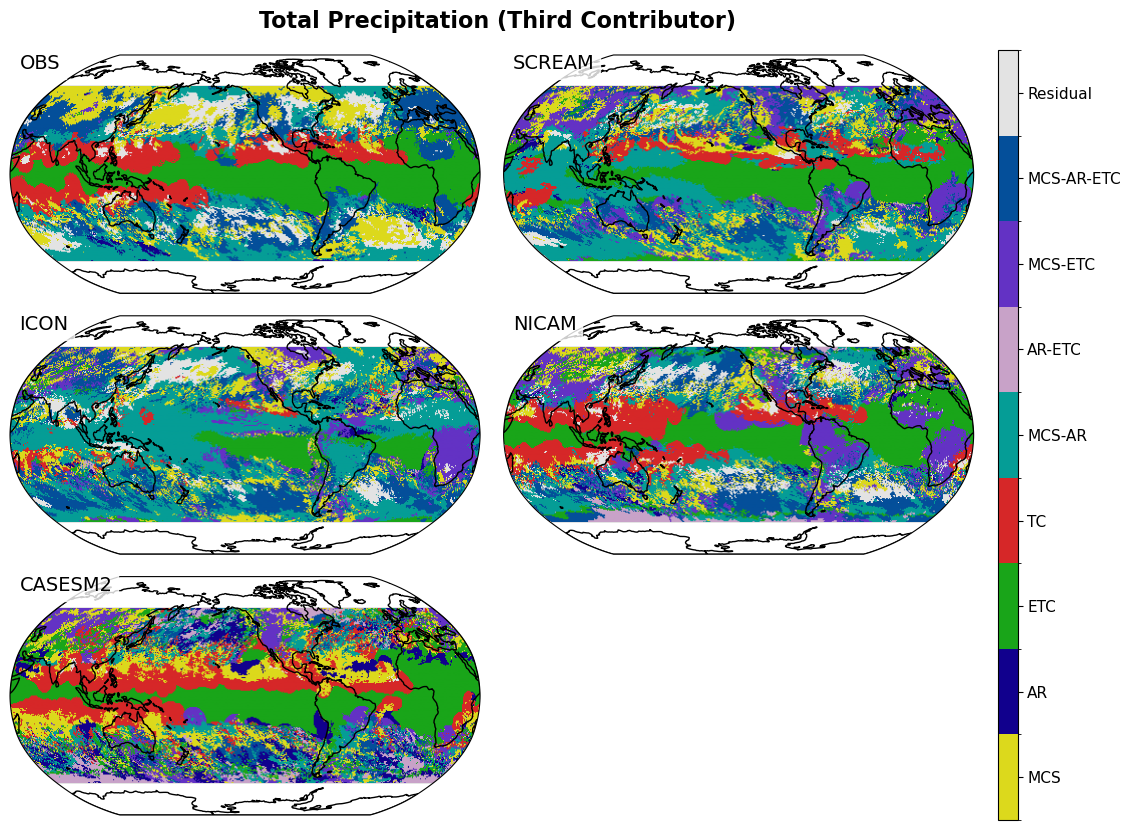

In [83]:
# Prepare data as 2D list
sources = ['obs', 'm1', 'm2', 'm3', 'm4']
nrow = 3
ncol = 2

# Create 2D lists for data and titles
da_list = []
titles = []
row_data = []
row_titles = []

for i, src in enumerate(sources):
    row_data.append(third_types_all.sel(source=src))
    row_titles.append(name_map_plot[src])
    
    # Start new row after ncol panels
    if (i + 1) % ncol == 0 or i == len(sources) - 1:
        # Pad with None if needed for last row
        while len(row_data) < ncol:
            row_data.append(None)
            row_titles.append('')
        
        da_list.append(row_data)
        titles.append(row_titles)
        row_data = []
        row_titles = []

# Plot the grid
fig = plot_ranked_types_grid(
    da_list=da_list,
    titles=titles,
    figname=f'{figdir}globalmap_precip_rank3_types_annual.png',
    figsize=(13, 10),
    fontsize=14,
    cb_fontsize=11,
    wspace=0.05,
    hspace=0.05,
    show_gridlines=False,
    figtitle='Total Precipitation (Third Contributor)',
    dpi=300,
    lat_range=(-60, 60)
)